In [11]:
import pandas as pd
import json
import re
from unidecode import unidecode

def gerar_chave(titulo, ano):
    titulo_limpo = unidecode(str(titulo)).lower()
    titulo_limpo = re.sub(r'[^a-z0-9\s]', '', titulo_limpo)
    titulo_limpo = re.sub(r'\s+', '_', titulo_limpo).strip('_')
    return f"{titulo_limpo}_{ano}"

# Carregar os dados
df_master = pd.read_json('../data/movies_master_completo.json')
df_reviews = pd.read_json('../data/reviews_analisadas_gemini.json')

# Criar a chave no master (assumindo que as colunas se chamam 'title' e 'release_year')
df_master['id_movie'] = df_master.apply(lambda row: gerar_chave(row['title'], row['release_year']), axis=1)

In [12]:
# Faz o merge usando o ID criado. O sufixo ajuda a identificar colunas duplicadas (como title e release_year)
df_merged = pd.merge(df_reviews, df_master, on='id_movie', how='inner', suffixes=('_rev', '_master'))

# Limpeza básica das colunas duplicadas
df_merged = df_merged.drop(columns=['title_master', 'release_year_master'])
df_merged = df_merged.rename(columns={'title_rev': 'title', 'release_year_rev': 'release_year'})

In [13]:
# 3.1 Extrair o Score Geral para uma coluna separada
df_merged['gemini_score'] = df_merged['analise_gemini'].apply(
    lambda x: x['metadados_grafico']['sentimento_geral_score'] if isinstance(x, dict) and 'metadados_grafico' in x else None
)

# 3.2 Isolar as métricas para a análise de tendências
# Vamos criar um dataframe específico onde cada linha é UMA TAG de um filme
registros_tags = []

for index, row in df_merged.iterrows():
    analise = row['analise_gemini']
    if isinstance(analise, dict) and 'metadados_grafico' in analise:
        metricas = analise['metadados_grafico'].get('metricas', [])
        for metrica in metricas:
            registros_tags.append({
                'id_movie': row['id_movie'],
                'title': row['title'],
                'genre': row.get('genre', []),
                'rating_publico': row['rating'], # Rating original do arquivo master
                'gemini_score': row['gemini_score'],
                'aspecto': metrica['aspecto'],
                'nivel': metrica['nivel'],
                'tag_tendencia': metrica['tag_tendencia']
            })

df_tags = pd.DataFrame(registros_tags)

In [14]:
print(df_tags.head(30))

                        id_movie                    title  \
0                  ausencia_2014                 Ausência   
1                  ausencia_2014                 Ausência   
2                  ausencia_2014                 Ausência   
3                  ausencia_2014                 Ausência   
4                  ausencia_2014                 Ausência   
5                  ausencia_2014                 Ausência   
6                  ausencia_2014                 Ausência   
7     o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
8     o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
9     o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
10    o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
11    o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
12    o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
13    o_ultimo_cine_drivein_2014   O Último Cine Drive-in   
14              um_homem_so_2015              Um Homem Só   
15              um_homem

In [15]:
df_tags[['rating_publico', 'gemini_score']].corr()

,rating_publico,gemini_score
rating_publico,1.00000,0.63724
gemini_score,0.63724,1.00000


In [16]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

output_dir = '../data/images'

# Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

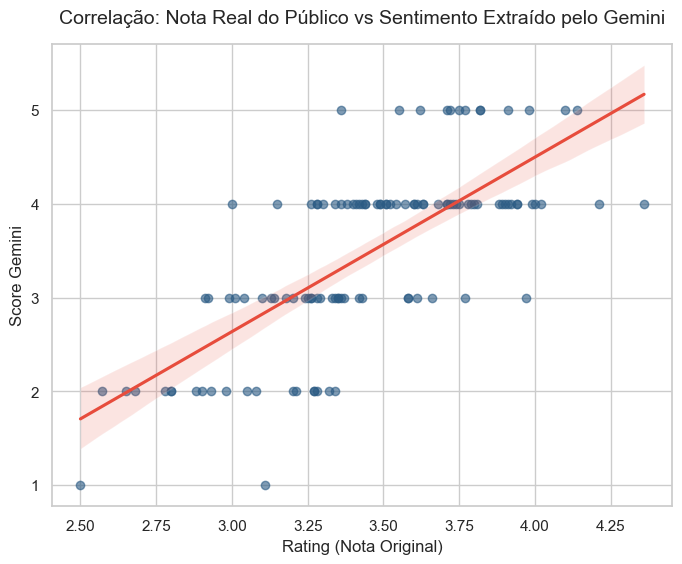

Salvo: ../data/images\correlacao_scores.png


In [17]:
# -----------------------------------------------------------------------
# INSIGHT 1: Correlação entre a Nota do Público e a Análise do Gemini
# Usa df_merged para ter um ponto por filme (e não duplicar por tag)

plt.figure(figsize=(8, 6))
sns.regplot(
    data=df_merged, 
    x='rating',
    y='gemini_score', 
    scatter_kws={'alpha':0.6, 'color': '#2b5b84'}, 
    line_kws={'color':'#e74c3c'}
)
plt.title('Correlação: Nota Real do Público vs Sentimento Extraído pelo Gemini', fontsize=14, pad=15) # pad dá um espaço entre o título e o gráfico
plt.xlabel('Rating (Nota Original)')
plt.ylabel('Score Gemini')

caminho_corr = os.path.join(output_dir, 'correlacao_scores.png') # identifica o sistema operacional e monta o caminho com as barras corretas
plt.savefig(caminho_corr, bbox_inches='tight', dpi=300) # tight para evitar espaços em branco e dpi para alta qualidade
plt.show()
plt.close()
print(f"Salvo: {caminho_corr}")

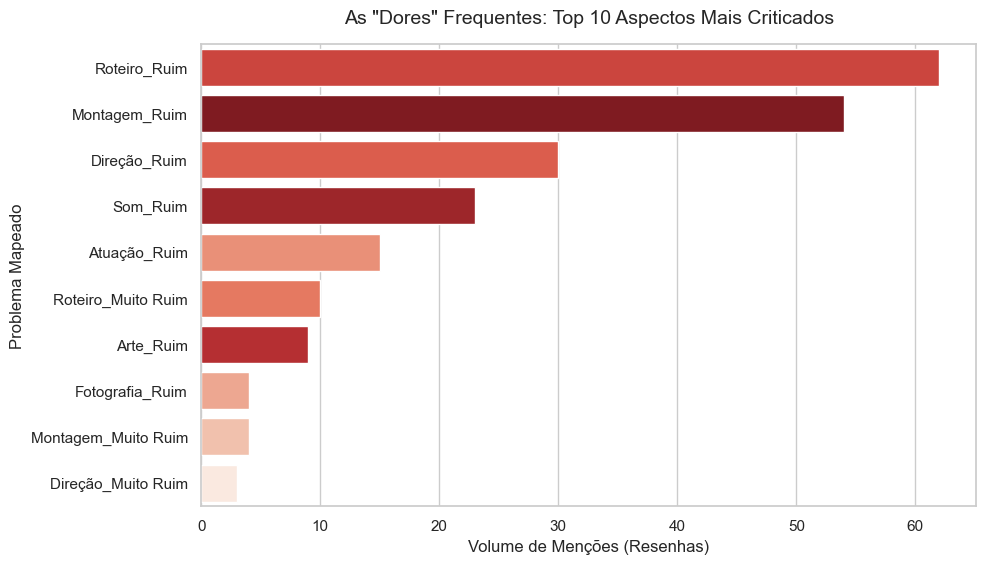

Salvo: ../data/images\top_dores_cinema.png


In [18]:
# -----------------------------------------------------------------------
# INSIGHT 2: A "Dor" do Cinema Nacional (Principais Reclamações Técnicas)
# Usa df_tags filtrando pelos piores níveis

negativas = df_tags[df_tags['nivel'].isin(['Ruim', 'Muito Ruim'])] # Filtra apenas tags negativas

plt.figure(figsize=(10, 6)) # Plota as 10 tags negativas mais frequentes

sns.countplot(
    data=negativas, 
    y='tag_tendencia',
    hue='tag_tendencia', 
    order=negativas['tag_tendencia'].value_counts().index[:10], 
    palette='Reds_r', # Gradiente vermelho para chamar atenção para o lado negativo
    legend=False
)
plt.title('As "Dores" Frequentes: Top 10 Aspectos Mais Criticados', fontsize=14, pad=15)
plt.xlabel('Volume de Menções (Resenhas)')
plt.ylabel('Problema Mapeado')

caminho_dores = os.path.join(output_dir, 'top_dores_cinema.png')
plt.savefig(caminho_dores, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Salvo: {caminho_dores}")

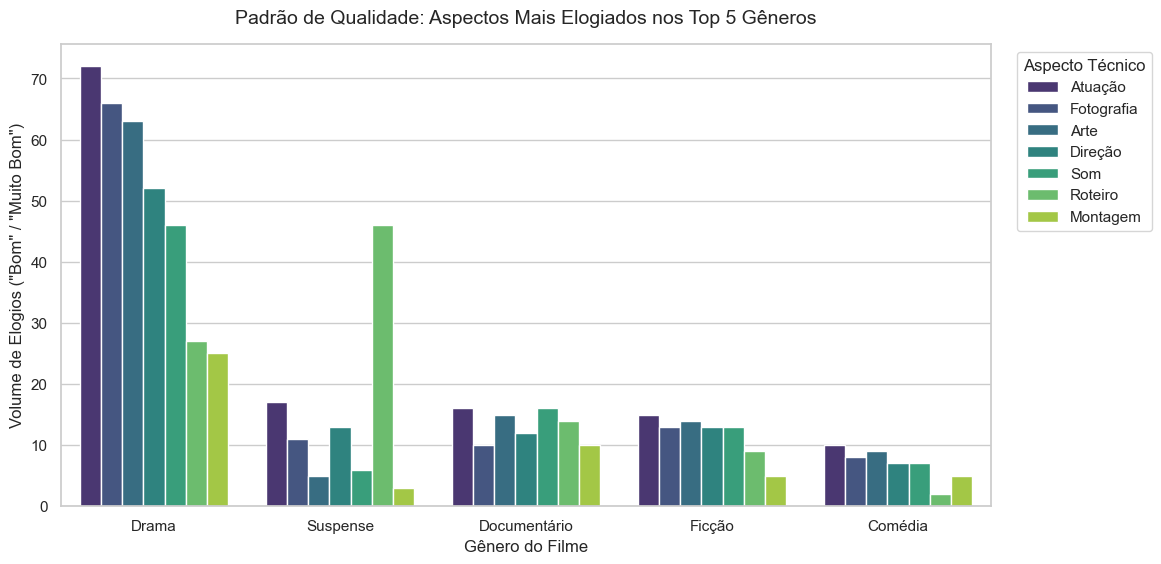

Salvo: ../data/images\forcas_por_genero.png


In [19]:
# -----------------------------------------------------------------------
# INSIGHT 3: Forças por Gênero (Onde cada gênero acerta?)
# Alguns filmes têm vários gêneros, precisando "explodir" a lista de gêneros

df_tags_exploded = df_tags.explode('genre')

top_5_generos = df_tags_exploded['genre'].value_counts().index[:5]
df_top_generos = df_tags_exploded[df_tags_exploded['genre'].isin(top_5_generos)]

# Filtramos apenas os elogios (Bom / Muito Bom)
positivas_genero = df_top_generos[df_top_generos['nivel'].isin(['Bom', 'Muito Bom'])]

plt.figure(figsize=(12, 6))
sns.countplot(
    data=positivas_genero, 
    x='genre', 
    hue='aspecto', 
    palette='viridis',
    order=top_5_generos
)
plt.title('Padrão de Qualidade: Aspectos Mais Elogiados nos Top 5 Gêneros', fontsize=14, pad=15)
plt.xlabel('Gênero do Filme')
plt.ylabel('Volume de Elogios ("Bom" / "Muito Bom")')
plt.legend(title='Aspecto Técnico', bbox_to_anchor=(1.02, 1), loc='upper left')

caminho_forcas = os.path.join(output_dir, 'forcas_por_genero.png')
plt.savefig(caminho_forcas, bbox_inches='tight', dpi=300)
plt.show()
plt.close()
print(f"Salvo: {caminho_forcas}")

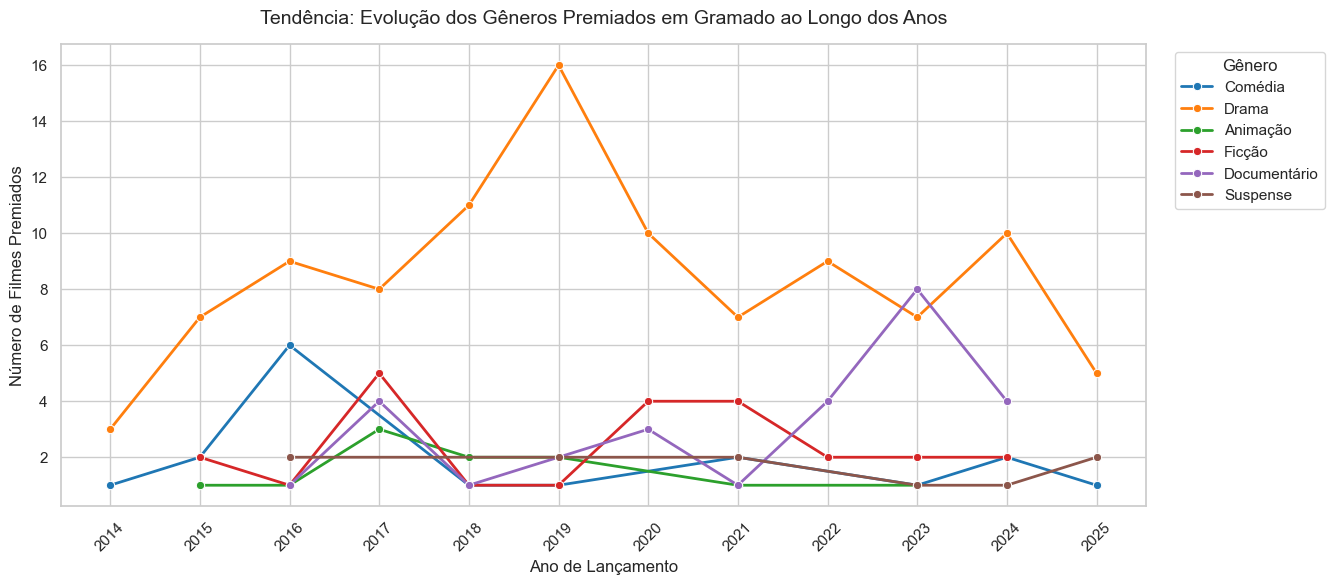

Salvo: ../data/images\tendencia_generos_anos.png


In [20]:
# -----------------------------------------------------------------------
# INSIGHT 4: Tendência de Gêneros Premiados ao Longo dos Anos
df_merged_exploded = df_merged.explode('genre')

top_generos_historico = df_merged_exploded['genre'].value_counts().index[:6]
df_trend = df_merged_exploded[df_merged_exploded['genre'].isin(top_generos_historico)]

# Agrupando por Ano e Gênero e contando o número de filmes
tendencia_ano = df_trend.groupby(['release_year', 'genre']).size().reset_index(name='qtd_filmes')

plt.figure(figsize=(14, 6))
sns.lineplot(
    data=tendencia_ano, 
    x='release_year', 
    y='qtd_filmes', 
    hue='genre', 
    marker='o', # Coloca uma bolinha em cada ano
    linewidth=2,
    palette='tab10'
)
plt.title('Tendência: Evolução dos Gêneros Premiados em Gramado ao Longo dos Anos', fontsize=14, pad=15)
plt.xlabel('Ano de Lançamento')
plt.ylabel('Número de Filmes Premiados')

plt.xticks(tendencia_ano['release_year'].unique(), rotation=45) 
plt.legend(title='Gênero', bbox_to_anchor=(1.02, 1), loc='upper left')

caminho_trend = os.path.join(output_dir, 'tendencia_generos_anos.png')
plt.savefig(caminho_trend, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_trend}")

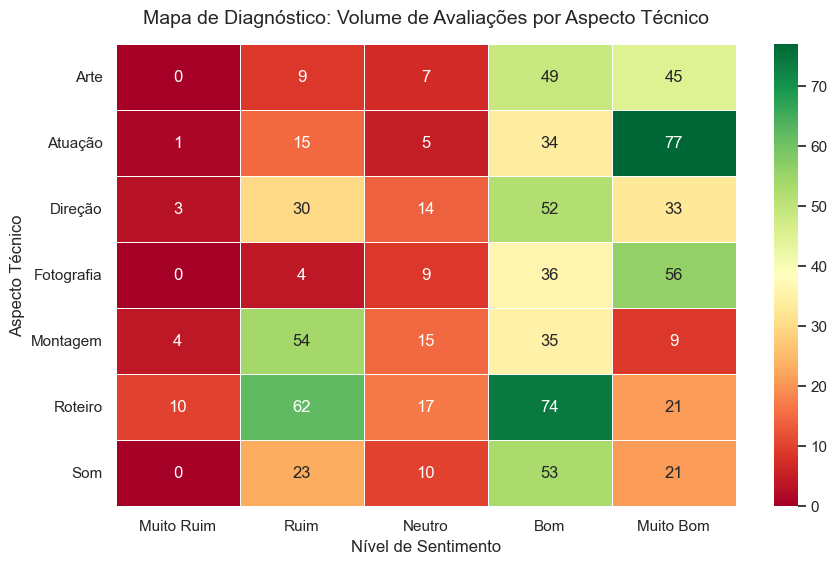

Salvo: ../data/images\heatmap_diagnostico.png


In [21]:
# -----------------------------------------------------------------------
# INSIGHT 5: Mapa de Calor (Heatmap) Diagnóstico da Indústria
# Cria uma tabela cruzada (Aspecto nas linhas, Nível nas colunas)
heatmap_data = pd.crosstab(df_tags['aspecto'], df_tags['nivel'])

# Forçar a ordem lógica das colunas (do pior para o melhor)
ordem_niveis = ['Muito Ruim', 'Ruim', 'Neutro', 'Bom', 'Muito Bom']
# Pega apenas as colunas que existem nos dados atuais para evitar erros
colunas_presentes = [col for col in ordem_niveis if col in heatmap_data.columns]
heatmap_data = heatmap_data[colunas_presentes]

plt.figure(figsize=(10, 6))
sns.heatmap(
    heatmap_data, 
    annot=True,      # Mostra os números dentro dos quadrados
    fmt='d',         # Formato inteiro
    cmap='RdYlGn',   # Paleta Red-Yellow-Green (Vermelho é ruim, Verde é bom)
    linewidths=.5
)
plt.title('Mapa de Diagnóstico: Volume de Avaliações por Aspecto Técnico', fontsize=14, pad=15)
plt.xlabel('Nível de Sentimento')
plt.ylabel('Aspecto Técnico')

caminho_heatmap = os.path.join(output_dir, 'heatmap_diagnostico.png')
plt.savefig(caminho_heatmap, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_heatmap}")

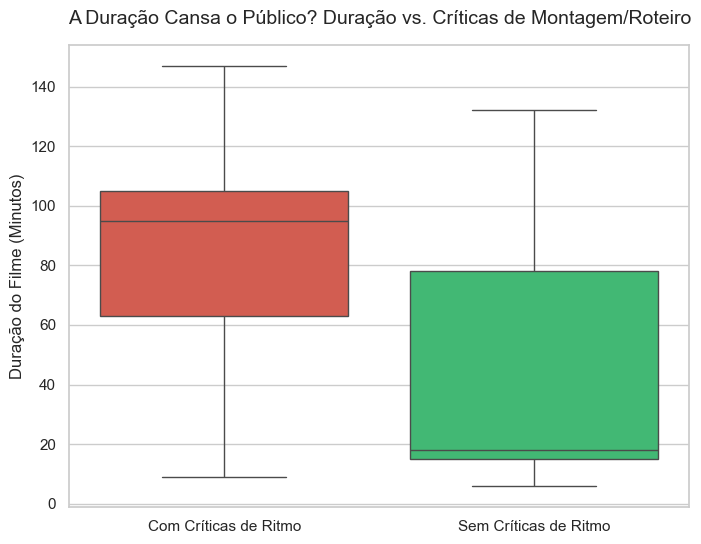

Salvo: ../data/images\boxplot_duracao_ritmo.png


In [22]:
# -----------------------------------------------------------------------
# INSIGHT 6: Impacto da Duração nos Problemas de Ritmo (Boxplot)
# Vamos criar uma flag no df_merged: O filme teve problemas de lentidão?
# Consideramos problema se o filme tem tags "Montagem_Ruim", "Montagem_Muito Ruim", etc.
tags_ritmo = ['Montagem_Ruim', 'Montagem_Muito Ruim', 'Roteiro_Ruim', 'Roteiro_Muito Ruim']

# Identifica os IDs dos filmes que receberam alguma crítica de ritmo
filmes_lentos = df_tags[df_tags['tag_tendencia'].isin(tags_ritmo)]['id_movie'].unique()

# Cria a coluna de classificação no dataframe principal
# Certifique-se de que a coluna de duração no seu master se chama 'duration'
df_merged['problema_ritmo'] = df_merged['id_movie'].apply(
    lambda x: 'Com Críticas de Ritmo' if x in filmes_lentos else 'Sem Críticas de Ritmo'
)

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=df_merged, 
    x='problema_ritmo', 
    y='duration', 
    hue='problema_ritmo',
    palette={'Com Críticas de Ritmo': '#e74c3c', 'Sem Críticas de Ritmo': '#2ecc71'},
    legend=False
)
plt.title('A Duração Cansa o Público? Duração vs. Críticas de Montagem/Roteiro', fontsize=14, pad=15)
plt.xlabel('')
plt.ylabel('Duração do Filme (Minutos)')

caminho_boxplot = os.path.join(output_dir, 'boxplot_duracao_ritmo.png')
plt.savefig(caminho_boxplot, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_boxplot}")

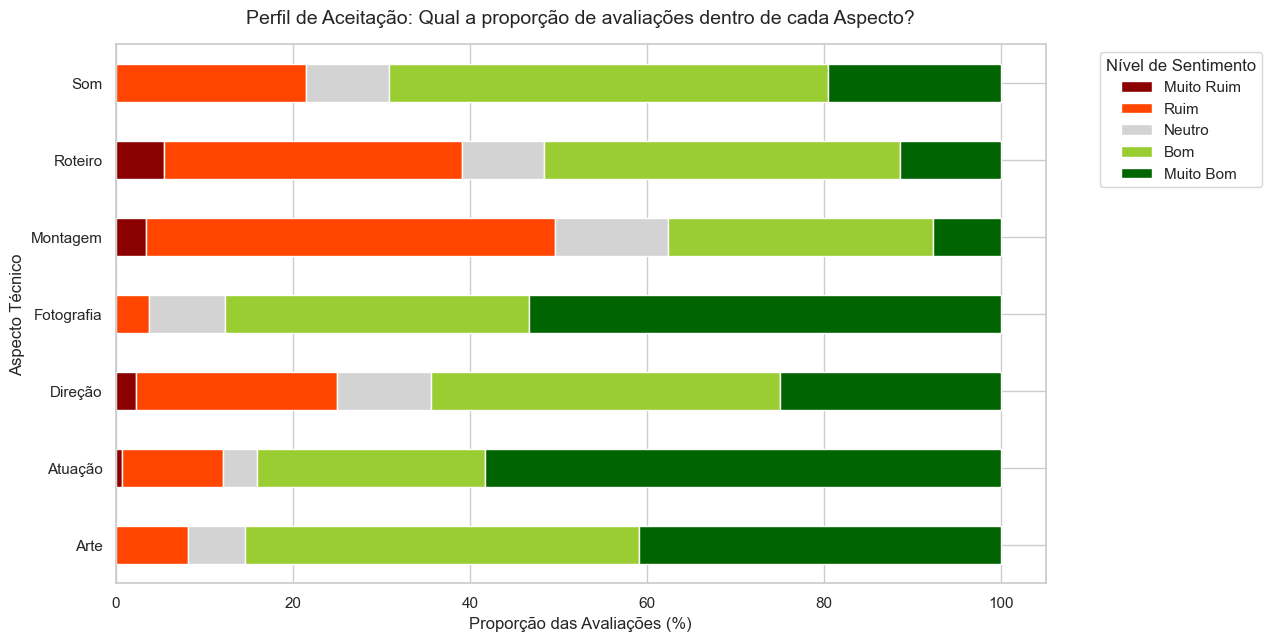

Salvo: ../data/images\barras_proporcao_sentimento.png
Gráficos gerados com sucesso!


In [23]:
# -----------------------------------------------------------------------
# INSIGHT 7: Proporção de Sentimentos (Polarização)
# Transforma os dados absolutos do heatmap em porcentagens (soma da linha = 100%)
heatmap_perc = heatmap_data.div(heatmap_data.sum(axis=1), axis=0) * 100

# Paleta de cores semântica
cores_niveis = {
    'Muito Ruim': '#8b0000', # Vermelho escuro
    'Ruim': '#ff4500',       # Laranja/Vermelho
    'Neutro': '#d3d3d3',     # Cinza
    'Bom': '#9acd32',        # Verde claro
    'Muito Bom': '#006400'   # Verde escuro
}


ax = heatmap_perc.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7),
    color=[cores_niveis.get(col, '#000000') for col in heatmap_perc.columns]
)

plt.title('Perfil de Aceitação: Qual a proporção de avaliações dentro de cada Aspecto?', fontsize=14, pad=15)
plt.xlabel('Proporção das Avaliações (%)')
plt.ylabel('Aspecto Técnico')

# Ajustando a legenda para fora do gráfico
plt.legend(title='Nível de Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')

caminho_proporcao = os.path.join(output_dir, 'barras_proporcao_sentimento.png')
plt.savefig(caminho_proporcao, bbox_inches='tight', dpi=300)
plt.show()
print(f"Salvo: {caminho_proporcao}")

print("Gráficos gerados com sucesso!")